# COAD PanCanAtlas Mutation Landscape Report

**English.** This notebook analyzes COAD (colon adenocarcinoma / a type of colon cancer) mutation records from the local TCGA PanCanAtlas database. It focuses on which genes are mutated most often, where mutations occur, recurrent mutation hotspots, tumor mutation burden, variant allele fraction, co-mutation patterns, and stage-level mutation frequencies.

**中文。** 这个 notebook 分析本地 TCGA PanCanAtlas 数据库里的 COAD（colon adenocarcinoma，结肠腺癌 / 一种结肠癌）突变记录。重点包括：哪些基因突变最多、突变位置在哪里、反复出现的突变热点、每个肿瘤样本的突变数量、VAF（variant allele fraction，突变等位基因比例 / 支持突变的测序 reads 占比）、共同突变模式，以及不同分期中的突变频率。

**Important scope note.** This is an exploratory data analysis report, not a clinical diagnosis. The numbers describe this local database snapshot.

## 1. Setup

The notebook reads database settings from environment variables. The password is intentionally not written into this file.

Required environment variable: `PGPASSWORD`.

Optional environment variables: `PGHOST`, `PGPORT`, `PGDATABASE`, `PGUSER`.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 80)

DB_HOST = os.environ.get("PGHOST", "postgres")
DB_PORT = int(os.environ.get("PGPORT", "5432"))
DB_NAME = os.environ.get("PGDATABASE", "bio")
DB_USER = os.environ.get("PGUSER", "bio")
DB_PASSWORD = os.environ.get("PGPASSWORD")

if not DB_PASSWORD:
    raise RuntimeError("Please set PGPASSWORD before running this notebook.")

DB_URL = URL.create(
    "postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)
engine = create_engine(DB_URL)

def read_sql(sql, params=None):
    return pd.read_sql_query(sql, engine, params=params)

def run_sql(sql):
    with psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
    ) as conn:
        conn.autocommit = True
        with conn.cursor() as cur:
            cur.execute(sql)

REPORT_DIR = Path.cwd()
REPORT_DIR

PosixPath('/workspace/coad-predictor-model/reports')

## 2. Build a COAD Mutation Cache

The source MAF table (`mc3_public_maf`) contains many cancer types. A MAF file (Mutation Annotation Format / 突变注释格式) is a table where each row is usually one DNA change in one tumor sample.

To make analysis faster, we create a small unlogged cache table containing only COAD rows and the columns needed in this report. This table can be safely rebuilt.

In [2]:
cache_sql = """
DROP TABLE IF EXISTS bio_tcga._nb_coad_pancanatlas_maf_cache;

CREATE UNLOGGED TABLE bio_tcga._nb_coad_pancanatlas_maf_cache AS
SELECT
  substring(m.tumor_sample_barcode from 1 for 12) AS patient_barcode,
  m.tumor_sample_barcode,
  c.gender,
  c.vital_status,
  COALESCE(NULLIF(c.ajcc_pathologic_tumor_stage, ''), '(missing)') AS ajcc_stage,
  c.age_at_initial_pathologic_diagnosis,
  c.os,
  c.os_time,
  m.hugo_symbol,
  m.entrez_gene_id,
  m.variant_classification,
  m.variant_type,
  m.chromosome,
  m.start_position,
  m.end_position,
  m.reference_allele,
  m.tumor_seq_allele2,
  m.hgvsc,
  m.hgvsp,
  m.hgvsp_short,
  m.exon_number,
  m.exon,
  m.protein_position,
  m.amino_acids,
  m.codons,
  m.impact,
  m.consequence,
  m.context,
  m.t_depth,
  m.t_ref_count,
  m.t_alt_count,
  m.n_depth,
  m.n_ref_count,
  m.n_alt_count,
  m.ncallers,
  m.filter,
  m.mutation_status,
  m.cosmic
FROM bio_tcga.mc3_public_maf m
JOIN bio_tcga.tcga_cdr_tcga_cdr c
  ON c.type = 'COAD'
 AND c.bcr_patient_barcode = substring(m.tumor_sample_barcode from 1 for 12);

CREATE INDEX IF NOT EXISTS _nb_coad_maf_sample_idx
  ON bio_tcga._nb_coad_pancanatlas_maf_cache(tumor_sample_barcode);
CREATE INDEX IF NOT EXISTS _nb_coad_maf_patient_idx
  ON bio_tcga._nb_coad_pancanatlas_maf_cache(patient_barcode);
CREATE INDEX IF NOT EXISTS _nb_coad_maf_gene_idx
  ON bio_tcga._nb_coad_pancanatlas_maf_cache(hugo_symbol);
CREATE INDEX IF NOT EXISTS _nb_coad_maf_position_idx
  ON bio_tcga._nb_coad_pancanatlas_maf_cache(chromosome, start_position);

ANALYZE bio_tcga._nb_coad_pancanatlas_maf_cache;
"""
run_sql(cache_sql)
print("COAD cache table rebuilt.")

COAD cache table rebuilt.


## 3. Dataset Overview

A patient barcode is the first 12 characters of a TCGA sample barcode. Here we count clinical patients, tumor samples with mutation data, mutation records, and mutated genes.

In [3]:
summary = read_sql("""
SELECT
  (SELECT COUNT(*) FROM bio_tcga.tcga_cdr_tcga_cdr WHERE type = 'COAD')::int AS clinical_patients,
  COUNT(*)::int AS mutation_records,
  COUNT(DISTINCT tumor_sample_barcode)::int AS tumor_samples_with_mutation_data,
  COUNT(DISTINCT patient_barcode)::int AS patients_with_mutation_data,
  COUNT(DISTINCT NULLIF(hugo_symbol, ''))::int AS mutated_genes
FROM bio_tcga._nb_coad_pancanatlas_maf_cache;
""")
display(summary)

clinical_stage = read_sql("""
SELECT ajcc_stage, COUNT(DISTINCT patient_barcode)::int AS patients
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
GROUP BY ajcc_stage
ORDER BY patients DESC, ajcc_stage;
""")
display(clinical_stage.head(12))

,clinical_patients,mutation_records,tumor_samples_with_mutation_data,patients_with_mutation_data,mutated_genes
0,459,277114,406,404,19586


,ajcc_stage,patients
0,Stage IIA,122
1,Stage I,67
2,Stage IIIB,53
3,Stage IV,37
4,Stage IIIC,34
5,Stage II,26
6,Stage III,19
7,Stage IVA,15
8,Stage IIB,8
9,Stage IIIA,8


## 4. Variant Types and Functional Classes

Variant type tells the DNA-level change, such as SNP/SNV (single-letter DNA change / 单个 DNA 字母改变), DEL (deletion / 缺失), or INS (insertion / 插入). Variant classification describes the functional effect, such as missense mutation (one amino acid changes / 一个氨基酸改变), nonsense mutation (early stop signal / 提前终止信号), or frameshift (reading frame shift / 读码框改变).

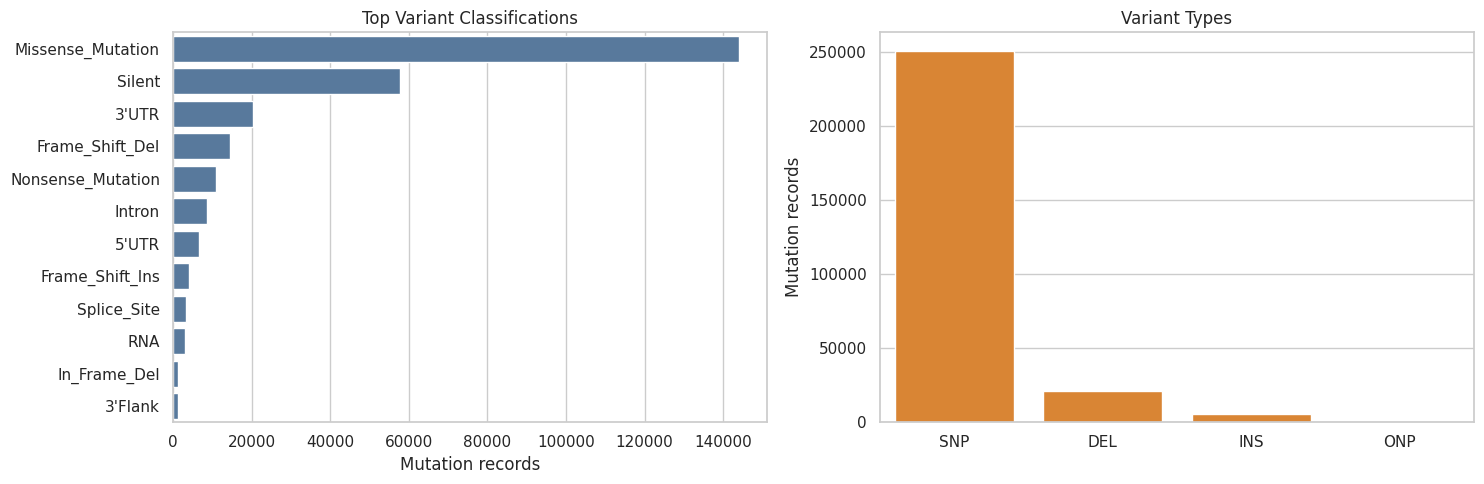

,label,mutation_records
0,Missense_Mutation,144030
1,Silent,57664
2,3'UTR,20267
3,Frame_Shift_Del,14562
4,Nonsense_Mutation,10835
5,Intron,8686
6,5'UTR,6607
7,Frame_Shift_Ins,3931
8,Splice_Site,3322
9,RNA,3125


,label,mutation_records
0,SNP,250637
1,DEL,21166
2,INS,5299
3,ONP,12


In [4]:
variant_class = read_sql("""
SELECT variant_classification AS label, COUNT(*)::int AS mutation_records
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
GROUP BY variant_classification
ORDER BY mutation_records DESC;
""")
variant_type = read_sql("""
SELECT variant_type AS label, COUNT(*)::int AS mutation_records
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
GROUP BY variant_type
ORDER BY mutation_records DESC;
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=variant_class.head(12), x="mutation_records", y="label", ax=axes[0], color="#4c78a8")
axes[0].set_title("Top Variant Classifications")
axes[0].set_xlabel("Mutation records")
axes[0].set_ylabel("")
sns.barplot(data=variant_type, x="label", y="mutation_records", ax=axes[1], color="#f58518")
axes[1].set_title("Variant Types")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mutation records")
plt.tight_layout()
plt.show()

display(variant_class.head(15))
display(variant_type)

## 5. Most Frequently Mutated Genes

The key denominator is tumor samples with mutation data. A gene's mutation frequency means: among COAD tumor samples in this local database, what percent have at least one mutation record in that gene?

,hugo_symbol,mutation_records,mutated_samples,sample_frequency_pct
0,APC,517,291,71.7
1,TTN,1035,247,60.8
2,TP53,260,226,55.7
3,KRAS,198,176,43.3
4,MUC16,373,140,34.5
5,SYNE1,348,138,34.0
6,PIK3CA,170,128,31.5
7,OBSCN,258,122,30.0
8,FAT4,247,116,28.6
9,ZFHX4,172,104,25.6


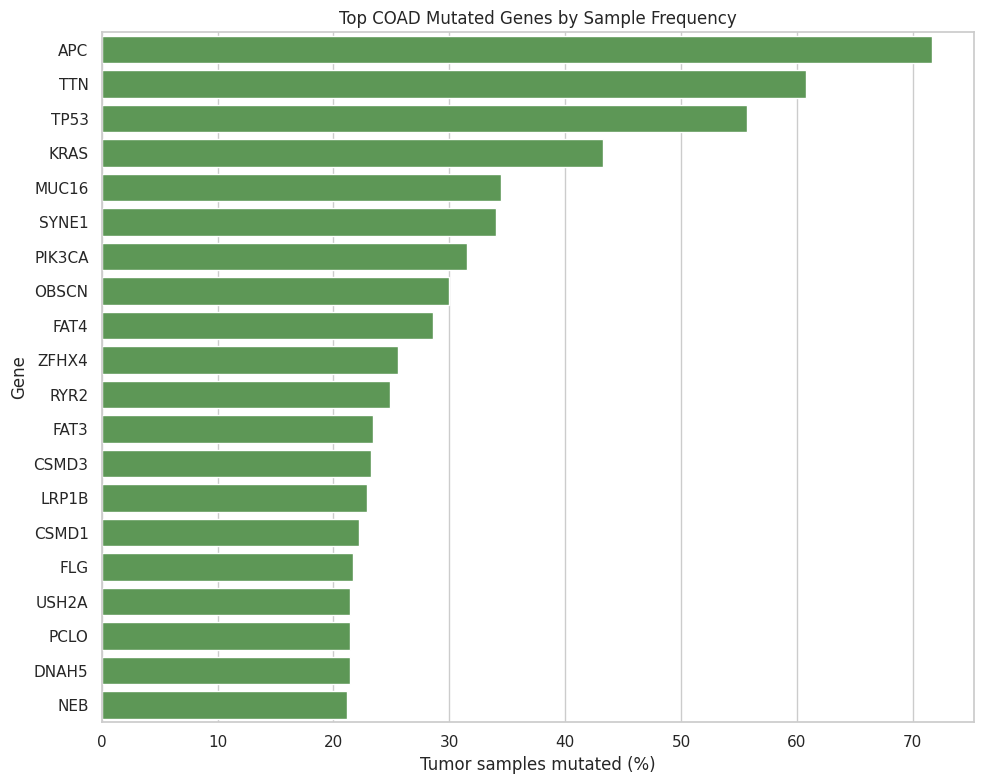

In [5]:
tumor_sample_count = int(summary.loc[0, "tumor_samples_with_mutation_data"])
top_genes = read_sql("""
SELECT
  hugo_symbol,
  COUNT(*)::int AS mutation_records,
  COUNT(DISTINCT tumor_sample_barcode)::int AS mutated_samples,
  ROUND(100.0 * COUNT(DISTINCT tumor_sample_barcode)
        / NULLIF((SELECT COUNT(DISTINCT tumor_sample_barcode)
                  FROM bio_tcga._nb_coad_pancanatlas_maf_cache), 0), 1) AS sample_frequency_pct
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
WHERE COALESCE(hugo_symbol, '') NOT IN ('', 'Unknown')
GROUP BY hugo_symbol
ORDER BY mutated_samples DESC, mutation_records DESC
LIMIT 30;
""")
display(top_genes)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_genes.head(20),
    x="sample_frequency_pct",
    y="hugo_symbol",
    color="#54a24b",
)
plt.title("Top COAD Mutated Genes by Sample Frequency")
plt.xlabel("Tumor samples mutated (%)")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

top_genes.to_csv(REPORT_DIR / "coad_pancanatlas_top_mutated_genes.csv", index=False)

## 6. Where Are the Mutations?

We look at mutation locations in three ways:

1. Chromosome distribution: which chromosomes contain more mutation records.
2. Recurrent genomic loci: exact DNA positions repeated in several samples.
3. Protein hotspots: repeated protein changes such as `KRAS p.G12D`.

A hotspot (repeated mutation position / 反复出现的突变位置) can be biologically important because different tumors independently hit the same position.

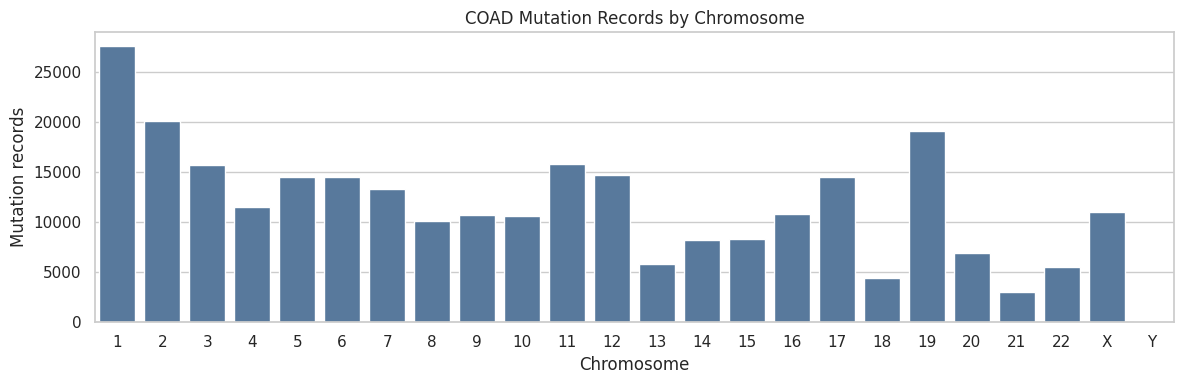

,hugo_symbol,chromosome,start_position,end_position,reference_allele,alt_allele,variant_classification,mutated_samples,mutation_records
0,DRD5,4,9785349,9785349,G,C,3'UTR,50,54
1,KRAS,12,25398284,25398284,C,T,Missense_Mutation,49,52
2,BRAF,7,140453136,140453136,A,T,Missense_Mutation,48,52
3,KRAS,12,25398284,25398284,C,A,Missense_Mutation,35,38
4,PIK3CA,3,178936091,178936091,G,A,Missense_Mutation,33,34
5,KRAS,12,25398281,25398281,C,T,Missense_Mutation,30,32
6,APC,5,112175639,112175639,C,T,Nonsense_Mutation,26,26
7,TP53,17,7578406,7578406,C,T,Missense_Mutation,24,25
8,RNF43,17,56435161,56435161,C,-,Frame_Shift_Del,23,25
9,DRD5,4,9785421,9785421,G,T,3'UTR,23,23


,hugo_symbol,hgvsp_short,protein_position,amino_acids,variant_classification,mutated_samples,mutation_records
0,KRAS,p.G12D,12,G/D,Missense_Mutation,49,52
1,BRAF,p.V600E,600,V/E,Missense_Mutation,48,52
2,KRAS,p.G12V,12,G/V,Missense_Mutation,35,38
3,PIK3CA,p.E545K,545,E/K,Missense_Mutation,33,34
4,KRAS,p.G13D,13,G/D,Missense_Mutation,30,32
5,APC,p.R1450*,1450,R/*,Nonsense_Mutation,26,26
6,TP53,p.R175H,175,R/H,Missense_Mutation,24,25
7,RNF43,p.G659Vfs*41,659,G/X,Frame_Shift_Del,23,25
8,DOCK3,p.P1852Qfs*45,1850,T/X,Frame_Shift_Del,19,19
9,ZBTB20,p.P692Lfs*43,692,P/X,Frame_Shift_Del,19,19


,hugo_symbol,exon_label,mutated_samples,mutation_records
0,APC,16/16,245,383
1,APC,7/16,23,23
2,APC,6/16,18,22
3,APC,14/16,16,16
4,APC,10/16,13,15
5,APC,9/16,13,14
6,APC,.,13,13
7,APC,12/16,10,11
8,APC,15/16,8,8
9,APC,13/16,3,4


In [6]:
chromosome_counts = read_sql("""
SELECT chromosome, COUNT(*)::int AS mutation_records
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
GROUP BY chromosome
ORDER BY
  CASE WHEN chromosome ~ '^[0-9]+$' THEN chromosome::int ELSE 100 END,
  chromosome;
""")

genomic_hotspots = read_sql("""
SELECT
  hugo_symbol,
  chromosome,
  start_position,
  end_position,
  reference_allele,
  tumor_seq_allele2 AS alt_allele,
  variant_classification,
  COUNT(DISTINCT tumor_sample_barcode)::int AS mutated_samples,
  COUNT(*)::int AS mutation_records
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
WHERE COALESCE(hugo_symbol, '') NOT IN ('', 'Unknown')
GROUP BY hugo_symbol, chromosome, start_position, end_position,
         reference_allele, tumor_seq_allele2, variant_classification
HAVING COUNT(DISTINCT tumor_sample_barcode) >= 3
ORDER BY mutated_samples DESC, mutation_records DESC
LIMIT 30;
""")

protein_hotspots = read_sql("""
SELECT
  hugo_symbol,
  hgvsp_short,
  protein_position,
  amino_acids,
  variant_classification,
  COUNT(DISTINCT tumor_sample_barcode)::int AS mutated_samples,
  COUNT(*)::int AS mutation_records
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
WHERE COALESCE(hugo_symbol, '') NOT IN ('', 'Unknown')
  AND hgvsp_short LIKE 'p.%%'
  AND hgvsp_short <> 'p.?'
GROUP BY hugo_symbol, hgvsp_short, protein_position, amino_acids, variant_classification
HAVING COUNT(DISTINCT tumor_sample_barcode) >= 3
ORDER BY mutated_samples DESC, mutation_records DESC
LIMIT 30;
""")

exon_summary = read_sql("""
SELECT
  hugo_symbol,
  COALESCE(NULLIF(exon_number, ''), NULLIF(exon, ''), '(missing)') AS exon_label,
  COUNT(DISTINCT tumor_sample_barcode)::int AS mutated_samples,
  COUNT(*)::int AS mutation_records
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
WHERE hugo_symbol IN ('APC', 'TP53', 'KRAS', 'PIK3CA', 'SMAD4')
GROUP BY hugo_symbol, COALESCE(NULLIF(exon_number, ''), NULLIF(exon, ''), '(missing)')
ORDER BY hugo_symbol, mutated_samples DESC, mutation_records DESC
LIMIT 60;
""")

plt.figure(figsize=(12, 4))
sns.barplot(data=chromosome_counts, x="chromosome", y="mutation_records", color="#4c78a8")
plt.title("COAD Mutation Records by Chromosome")
plt.xlabel("Chromosome")
plt.ylabel("Mutation records")
plt.tight_layout()
plt.show()

display(genomic_hotspots)
display(protein_hotspots)
display(exon_summary)

genomic_hotspots.to_csv(REPORT_DIR / "coad_pancanatlas_genomic_hotspots.csv", index=False)
protein_hotspots.to_csv(REPORT_DIR / "coad_pancanatlas_protein_hotspots.csv", index=False)

## 7. Tumor Mutation Burden and VAF

Tumor mutation burden (TMB / 肿瘤突变负荷) here means the number of mutation records per tumor sample. This is a simple count, not a clinically standardized TMB per megabase.

VAF (variant allele fraction / 突变等位基因比例) is calculated as `t_alt_count / t_depth`, meaning the fraction of tumor sequencing reads that support the mutated allele.

,mutation_records,mutated_genes
count,406.0,406.0
mean,682.5,553.2
std,1460.9,1020.0
min,18.0,18.0
25%,133.0,127.2
50%,181.5,169.5
75%,274.8,242.8
90%,1889.5,1706.5
95%,3093.0,2562.5
max,13582.0,7792.0


,tumor_sample_barcode,patient_barcode,ajcc_stage,vital_status,mutation_records,mutated_genes
0,TCGA-CA-6717-01A-11D-1835-10,TCGA-CA-6717,Stage IIA,Alive,13582,7792
1,TCGA-AA-A010-01A-01D-A17O-10,TCGA-AA-A010,Stage IIB,Alive,11326,7256
2,TCGA-AZ-4315-01A-01D-1408-10,TCGA-AZ-4315,Stage IIA,Alive,9853,6540
3,TCGA-AA-3984-01A-02D-1981-10,TCGA-AA-3984,Stage IIA,Alive,7648,5410
4,TCGA-AA-A00N-01A-02D-A17O-10,TCGA-AA-A00N,Stage IIB,Dead,7410,5249
5,TCGA-CK-4951-01A-01D-1408-10,TCGA-CK-4951,Stage IIA,Dead,6802,4888
6,TCGA-A6-2686-01A-01D-1408-10,TCGA-A6-2686,Stage IIA,Dead,6207,2799
7,TCGA-A6-5665-01A-01D-1650-10,TCGA-A6-5665,Stage IIA,Alive,5506,2522
8,TCGA-AA-3977-01A-01W-0995-10,TCGA-AA-3977,[Not Available],Alive,4935,3745
9,TCGA-AA-3510-01A-01D-1408-10,TCGA-AA-3510,Stage II,Alive,4614,3591


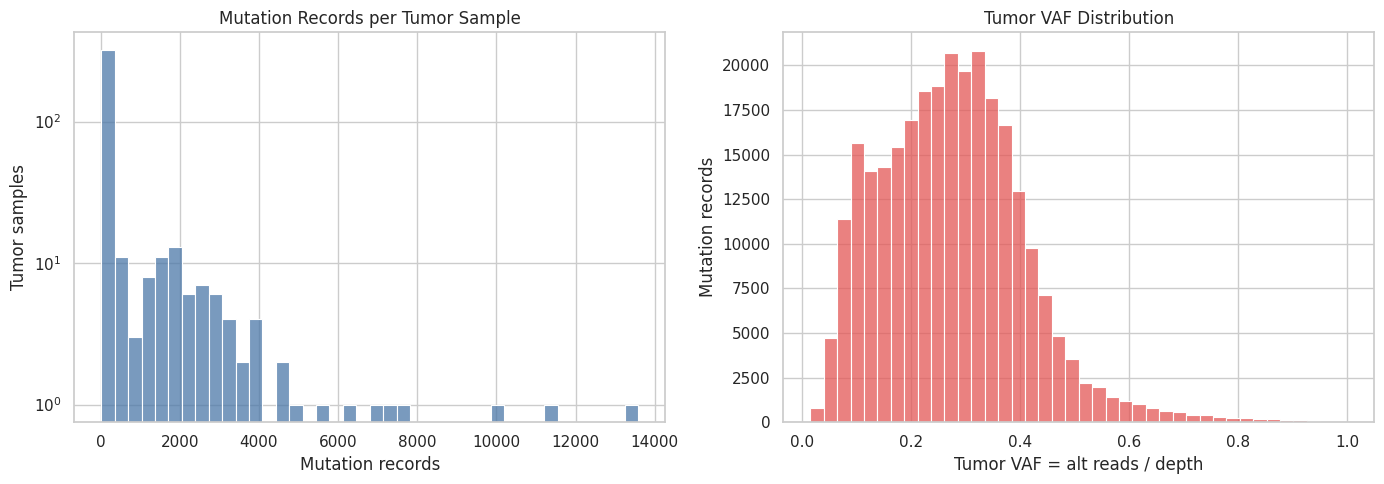

In [7]:
burden = read_sql("""
SELECT
  tumor_sample_barcode,
  patient_barcode,
  ajcc_stage,
  vital_status,
  COUNT(*)::int AS mutation_records,
  COUNT(DISTINCT NULLIF(hugo_symbol, ''))::int AS mutated_genes
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
GROUP BY tumor_sample_barcode, patient_barcode, ajcc_stage, vital_status
ORDER BY mutation_records DESC;
""")
burden_summary = burden[["mutation_records", "mutated_genes"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(1)
display(burden_summary)
display(burden.head(15))

vaf = read_sql("""
SELECT
  CASE
    WHEN t_depth ~ '^[0-9]+$'
     AND t_alt_count ~ '^[0-9]+$'
     AND t_depth::numeric > 0
    THEN t_alt_count::numeric / t_depth::numeric
  END AS tumor_vaf,
  variant_classification,
  hugo_symbol
FROM bio_tcga._nb_coad_pancanatlas_maf_cache;
""")
vaf = vaf.dropna(subset=["tumor_vaf"])
vaf = vaf[(vaf["tumor_vaf"] >= 0) & (vaf["tumor_vaf"] <= 1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(burden["mutation_records"], bins=40, ax=axes[0], color="#4c78a8")
axes[0].set_title("Mutation Records per Tumor Sample")
axes[0].set_xlabel("Mutation records")
axes[0].set_ylabel("Tumor samples")
axes[0].set_yscale("log")

sns.histplot(vaf["tumor_vaf"], bins=40, ax=axes[1], color="#e45756")
axes[1].set_title("Tumor VAF Distribution")
axes[1].set_xlabel("Tumor VAF = alt reads / depth")
axes[1].set_ylabel("Mutation records")
plt.tight_layout()
plt.show()

burden.to_csv(REPORT_DIR / "coad_pancanatlas_sample_mutation_burden.csv", index=False)

## 8. Co-Mutation Patterns Among Top Genes

Co-mutation (共同突变) means the same tumor sample has mutations in two genes. This heatmap shows the percent of tumor samples that have both genes mutated.

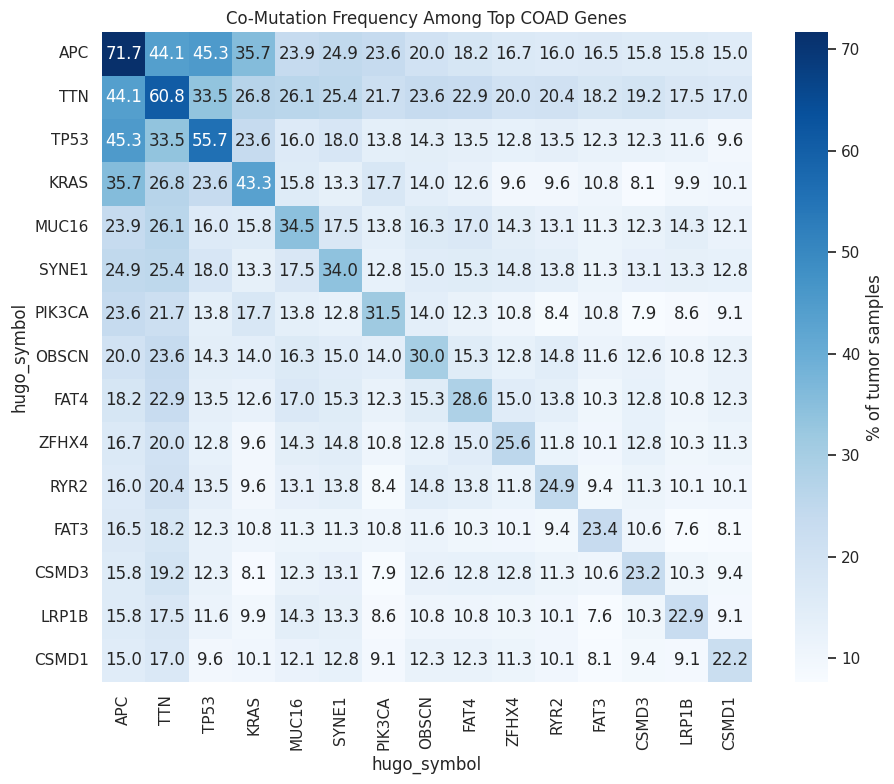

hugo_symbol,APC,TTN,TP53,KRAS,MUC16,SYNE1,PIK3CA,OBSCN,FAT4,ZFHX4,RYR2,FAT3,CSMD3,LRP1B,CSMD1
hugo_symbol,,,,,,,,,,,,,,,
APC,71.7,44.1,45.3,35.7,23.9,24.9,23.6,20.0,18.2,16.7,16.0,16.5,15.8,15.8,15.0
TTN,44.1,60.8,33.5,26.8,26.1,25.4,21.7,23.6,22.9,20.0,20.4,18.2,19.2,17.5,17.0
TP53,45.3,33.5,55.7,23.6,16.0,18.0,13.8,14.3,13.5,12.8,13.5,12.3,12.3,11.6,9.6
KRAS,35.7,26.8,23.6,43.3,15.8,13.3,17.7,14.0,12.6,9.6,9.6,10.8,8.1,9.9,10.1
MUC16,23.9,26.1,16.0,15.8,34.5,17.5,13.8,16.3,17.0,14.3,13.1,11.3,12.3,14.3,12.1
SYNE1,24.9,25.4,18.0,13.3,17.5,34.0,12.8,15.0,15.3,14.8,13.8,11.3,13.1,13.3,12.8
PIK3CA,23.6,21.7,13.8,17.7,13.8,12.8,31.5,14.0,12.3,10.8,8.4,10.8,7.9,8.6,9.1
OBSCN,20.0,23.6,14.3,14.0,16.3,15.0,14.0,30.0,15.3,12.8,14.8,11.6,12.6,10.8,12.3
FAT4,18.2,22.9,13.5,12.6,17.0,15.3,12.3,15.3,28.6,15.0,13.8,10.3,12.8,10.8,12.3


In [8]:
top_gene_list = top_genes.head(15)["hugo_symbol"].tolist()
sample_gene = read_sql("""
SELECT tumor_sample_barcode, hugo_symbol, COUNT(*)::int AS mutation_records
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
WHERE hugo_symbol = ANY(%(genes)s)
GROUP BY tumor_sample_barcode, hugo_symbol;
""", params={"genes": top_gene_list})

binary = (
    sample_gene.assign(mutated=1)
    .pivot_table(index="tumor_sample_barcode", columns="hugo_symbol", values="mutated", fill_value=0)
    .reindex(columns=top_gene_list, fill_value=0)
)
# Include samples with no mutation in the selected genes so percentages use all tumor samples.
all_samples = burden["tumor_sample_barcode"].sort_values().unique()
binary = binary.reindex(all_samples, fill_value=0)
co_counts = binary.T.dot(binary)
co_pct = co_counts / len(binary) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(co_pct, cmap="Blues", annot=True, fmt=".1f", square=True, cbar_kws={"label": "% of tumor samples"})
plt.title("Co-Mutation Frequency Among Top COAD Genes")
plt.tight_layout()
plt.show()

display(co_pct.round(1))
co_pct.round(2).to_csv(REPORT_DIR / "coad_pancanatlas_top_gene_comutation_pct.csv")

## 9. Mutation Frequency by AJCC Stage

AJCC stage (a cancer staging system / 癌症分期系统) roughly describes how far the cancer has grown or spread. This plot shows, for each stage group, what percent of samples have each top gene mutated.

This is descriptive only. It does not prove that a gene causes a stage difference.

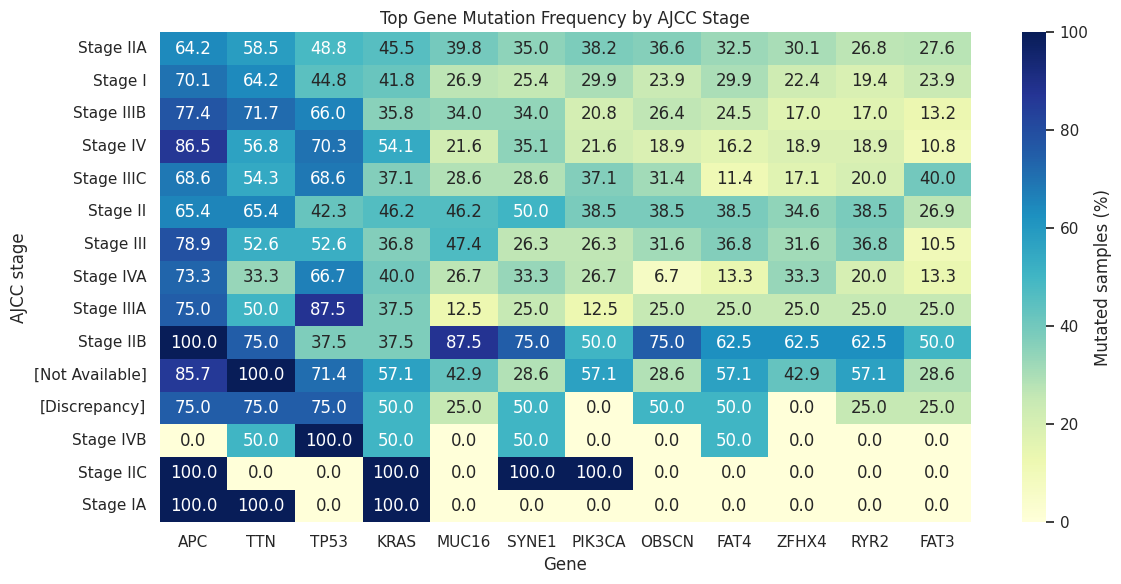

,ajcc_stage,hugo_symbol,mutated_samples,stage_samples,mutation_frequency_pct
0,[Discrepancy],APC,3,4,75.0
1,[Discrepancy],FAT3,1,4,25.0
2,[Discrepancy],FAT4,2,4,50.0
3,[Discrepancy],KRAS,2,4,50.0
4,[Discrepancy],MUC16,1,4,25.0
5,[Discrepancy],OBSCN,2,4,50.0
6,[Discrepancy],PIK3CA,0,4,0.0
7,[Discrepancy],RYR2,1,4,25.0
8,[Discrepancy],SYNE1,2,4,50.0
9,[Discrepancy],TP53,3,4,75.0


In [9]:
stage_gene = read_sql("""
WITH stage_denominator AS (
  SELECT ajcc_stage, COUNT(DISTINCT tumor_sample_barcode)::numeric AS stage_samples
  FROM bio_tcga._nb_coad_pancanatlas_maf_cache
  GROUP BY ajcc_stage
),
gene_counts AS (
  SELECT ajcc_stage, hugo_symbol, COUNT(DISTINCT tumor_sample_barcode)::numeric AS mutated_samples
  FROM bio_tcga._nb_coad_pancanatlas_maf_cache
  WHERE hugo_symbol = ANY(%(genes)s)
  GROUP BY ajcc_stage, hugo_symbol
)
SELECT
  d.ajcc_stage,
  g.hugo_symbol,
  COALESCE(c.mutated_samples, 0)::int AS mutated_samples,
  d.stage_samples::int AS stage_samples,
  ROUND(100.0 * COALESCE(c.mutated_samples, 0) / NULLIF(d.stage_samples, 0), 1) AS mutation_frequency_pct
FROM stage_denominator d
CROSS JOIN (SELECT unnest(%(genes)s::text[]) AS hugo_symbol) g
LEFT JOIN gene_counts c
  ON c.ajcc_stage = d.ajcc_stage
 AND c.hugo_symbol = g.hugo_symbol
ORDER BY d.ajcc_stage, g.hugo_symbol;
""", params={"genes": top_gene_list[:12]})

stage_order = (
    stage_gene.groupby("ajcc_stage")["stage_samples"].max()
    .sort_values(ascending=False)
    .index.tolist()
)
stage_matrix = (
    stage_gene.pivot(index="ajcc_stage", columns="hugo_symbol", values="mutation_frequency_pct")
    .reindex(index=stage_order, columns=top_gene_list[:12])
)

plt.figure(figsize=(12, 6))
sns.heatmap(stage_matrix, cmap="YlGnBu", annot=True, fmt=".1f", cbar_kws={"label": "Mutated samples (%)"})
plt.title("Top Gene Mutation Frequency by AJCC Stage")
plt.xlabel("Gene")
plt.ylabel("AJCC stage")
plt.tight_layout()
plt.show()

display(stage_gene.head(40))
stage_gene.to_csv(REPORT_DIR / "coad_pancanatlas_stage_gene_frequency.csv", index=False)

## 10. Short Biological Reading

**English.** In COAD, the most frequent genes are expected to include classic colorectal cancer genes such as APC, TP53, KRAS, PIK3CA, and SMAD4. APC is often involved early in colorectal tumor development; TP53 is linked to DNA damage control; KRAS and PIK3CA affect growth signaling; SMAD4 is part of the TGF-beta pathway (a cell communication pathway that can control growth).

**中文。** 在 COAD 中，常见高频突变基因通常包括 APC、TP53、KRAS、PIK3CA、SMAD4 等经典结直肠癌相关基因。APC 常和结直肠肿瘤早期发展有关；TP53 和 DNA 损伤控制有关；KRAS、PIK3CA 会影响细胞生长信号；SMAD4 属于 TGF-beta 通路（调节细胞生长和交流的一条信号通路）。

**How to read hotspots.** If one exact protein change appears in many samples, it may be a driver mutation (a mutation that helps cancer grow / 推动癌症生长的突变). But this notebook only counts recurrence; formal driver-gene analysis needs additional statistical modeling and biological validation.

In [10]:
key_gene_records = read_sql("""
SELECT
  hugo_symbol,
  variant_classification,
  hgvsp_short,
  chromosome,
  start_position,
  reference_allele,
  tumor_seq_allele2 AS alt_allele,
  tumor_sample_barcode,
  ajcc_stage,
  t_depth,
  t_alt_count,
  ncallers
FROM bio_tcga._nb_coad_pancanatlas_maf_cache
WHERE hugo_symbol IN ('APC', 'TP53', 'KRAS', 'PIK3CA', 'SMAD4')
ORDER BY hugo_symbol, tumor_sample_barcode, chromosome, start_position
LIMIT 30;
""")
display(key_gene_records)

,hugo_symbol,variant_classification,hgvsp_short,chromosome,start_position,reference_allele,alt_allele,tumor_sample_barcode,ajcc_stage,t_depth,t_alt_count,ncallers
0,APC,Nonsense_Mutation,p.R876*,5,112173917,C,T,TCGA-3L-AA1B-01A-11D-A36X-10,Stage I,88,38,5
1,APC,Nonsense_Mutation,p.R1450*,5,112175639,C,T,TCGA-3L-AA1B-01A-11D-A36X-10,Stage I,128,10,2
2,APC,Nonsense_Mutation,p.E941*,5,112174112,G,T,TCGA-4T-AA8H-01A-11D-A40P-10,Stage IIA,126,31,5
3,APC,Frame_Shift_Ins,p.H1490Yfs*18,5,112175756,-,TA,TCGA-4T-AA8H-01A-11D-A40P-10,Stage IIA,182,59,3
4,APC,Frame_Shift_Del,p.D1486Ifs*21,5,112175746,T,-,TCGA-5M-AAT4-01A-11D-A40P-10,Stage IV,198,71,3
5,APC,Nonsense_Mutation,p.R876*,5,112173917,C,T,TCGA-5M-AAT6-01A-11D-A40P-10,Stage IV,103,15,4
6,APC,Frame_Shift_Del,p.N1455Ifs*18,5,112175651,A,-,TCGA-5M-AAT6-01A-11D-A40P-10,Stage IV,209,28,3
7,APC,Nonsense_Mutation,p.E1345*,5,112175324,G,T,TCGA-5M-AATE-01A-11D-A40P-10,Stage IIA,110,89,5
8,APC,Frame_Shift_Del,p.S943Qfs*12,5,112174117,T,-,TCGA-A6-2671-01A-01D-1408-10,Stage IV,57,10,3
9,APC,Frame_Shift_Del,p.S943Qfs*12,5,112174117,T,-,TCGA-A6-2671-01A-01D-1408-10,Stage IV,57,10,3


## 11. Limitations and Next Steps

**Limitations.**

- This report counts mutation records from MC3 MAF; it does not re-run variant calling (finding DNA sequence differences from raw sequencing reads / 从原始测序数据中重新寻找 DNA 差异).
- TMB here is a simple mutation-record count, not a clinically standardized mutations-per-megabase value.
- Stage and survival relationships are observational; they can be affected by confounders (other variables that mix up the explanation / 混杂因素).
- `scikit-bio` is not used as a main tool here because this task analyzes annotated cancer mutation tables, not microbiome diversity, phylogenetic trees, FASTA/FASTQ sequence alignment, or UniFrac/PCoA workflows.

**Next steps.**

- Compare high-mutation-burden samples with MSI/POLE annotations if available.
- Add survival analysis for selected genes, with clear caveats and enough sample size.
- Connect mutation status with RNA-seq expression for the same patients.
- Review recurrent hotspots in external cancer knowledge bases before treating them as driver mutations.